# Part 2 - Modelling
## Chapter 8 - Feature Importance

### 8.1 Using the code presented in Section 8.6:
#### (a) Generate a dataset (X, y).

In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification


def get_test_data(n_features=40, n_informative=10, n_redundant=10, n_samples=10000):
    # generate a random dataset for a classification problem
    X, labels = make_classification(n_samples=n_samples, n_features=n_features,
                                    n_informative=n_informative, n_redundant=n_redundant, random_state=0,
                                    shuffle=False)
    indices = pd.date_range(end=pd.Timestamp.today(), periods=n_samples, freq='min').astype('int64') // 10**6
    X, labels = pd.DataFrame(X, index=indices), pd.Series(labels, index=indices).to_frame('bin')
    columns = [f'I_{i}' for i in range(n_informative)]
    columns += [f'R_{i}' for i in range(n_redundant)]
    columns += [f'N_{i}' for i in range(n_features - len(columns))]
    X.columns = columns
    labels['w'] = 1. / labels.shape[0]
    labels['t1'] = pd.Series(labels.index, index=labels.index)
    return X, labels


X, y = get_test_data(n_features=40, n_informative=10, n_redundant=10, n_samples=10000)

#### 8.1 (b) Apply a PCA transformation on X, which we denote Ẋ .

In [9]:
from sklearn.decomposition import PCA

pca = PCA()
X_1 = pca.fit_transform(X)
X_1 = pd.DataFrame(X_1, columns=[f'PC_{i}' for i in np.arange(len(X_1[1]))], index=X.index)

#### 8.1 (c) Compute MDI, MDA, and SFI feature importance on (Ẋ , y), where the base estimator is RF.

In [10]:
from typing import Literal, Any
import matplotlib.pyplot as plt


def plot_feature_importance(
    imp: pd.DataFrame,
    oob: float,
    oos: float,
    method: Literal["MDI", "MDA", "SFI"],
    tag: int = 0,
    sim_num: int = 0,
        **kwargs: Any
):
    # plot mean imp bars with std
    plt.figure(figsize=(10, imp.shape[0] / 5.0))
    imp = imp.sort_values("mean", ascending=True)
    ax = imp["mean"].plot(
        kind="barh", color="b", alpha=0.25, xerr=imp["std"], error_kw={"ecolor": "r"}
    )
    if method == "MDI":
        plt.xlim([0, imp.sum(axis=1).max()])
    plt.axvline(1.0 / imp.shape[0], linewidth=1, color="r", linestyle="dotted")
    ax.get_yaxis().set_visible(False)
    for i, j in zip(ax.patches, imp.index):
        ax.text(
            i.get_width() / 2,
            i.get_y() + i.get_height() / 2,
            j,
            ha="center",
            va="center",
            color="black",
        )
    plt.title(f"tag={tag} | simNum={sim_num} | oob={oob:.4f} | oos={oos:.4}")
    plt.show()


In [11]:
import importlib
from afml.modelling import feature_importance
from afml.modelling import cross_validation

importlib.reload(cross_validation)
importlib.reload(feature_importance)
from afml.modelling.feature_importance import feat_importance
from itertools import product


def test_func(
        X: pd.DataFrame,
        y: pd.Series,
        n_estimators: int = 1000,
        n_splits: int = 10,
        methods: list[Literal["MDI", "MDA", "SFI"]] | None = None,
        max_features: list[int | None] | None = None,
        max_samples: list[float | None] | None = None,
        scoring: list[str] | None = None,
        min_w_leaf: list[float] | None = None,
):
    # test the performance of the feat importance functions on artificial data
    # Nr noise features = n_features—n_informative—n_redundant
    methods = methods or ["MDI", "MDA", "SFI"]
    max_features = max_features or [1]
    max_samples = max_samples or [1.]
    scoring = scoring or ['accuracy']
    min_w_leaf = min_w_leaf or [0.]
    dict0 = {'min_w_leaf': min_w_leaf,
             'scoring': scoring,
             'method': methods,
             'max_samples': max_samples, 'max_features': max_features,}
    jobs = (dict(zip(dict0, i)) for i in product(*dict0.values()))
    out = []
    kwargs = {'n_estimators': n_estimators, 'n_splits': n_splits}
    for job in jobs:
        job['sim_num'] = f"{job['method']}_{job['scoring']}_{job['min_w_leaf']:.2f}_{job['max_samples']}"
        print(job['sim_num'])
        kwargs.update(job)
        imp, oob, oos = feat_importance(X=X, labels=y, **kwargs)
        plot_feature_importance(imp=imp, oob=oob, oos=oos, **kwargs)
        total_mean = imp['mean'].abs().sum()
        if total_mean > 0:
            df0 = imp[['mean']] / total_mean
        else:
            df0 = imp[['mean']].copy()
            df0.loc['mean'] = 1. / len(df0)
        df0['type'] = [i[0] for i in df0.index]
        df0 = df0.groupby('type')['mean'].sum().to_dict()
        df0.update({'oob': oob, 'oos': oos})
        df0.update(job)
        out.append(df0)
    return out

SFI_accuracy_0.00_1.0


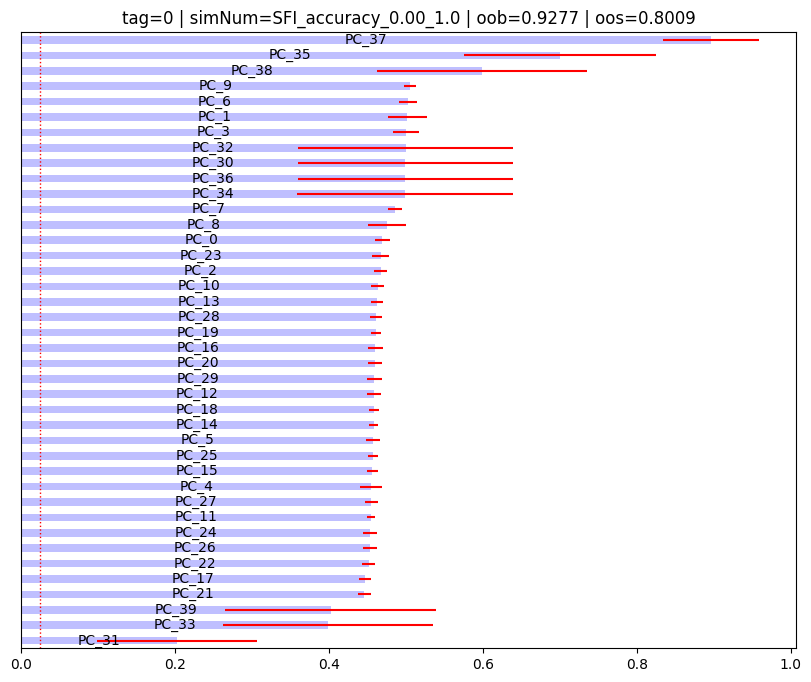

MDI_accuracy_0.00_1.0


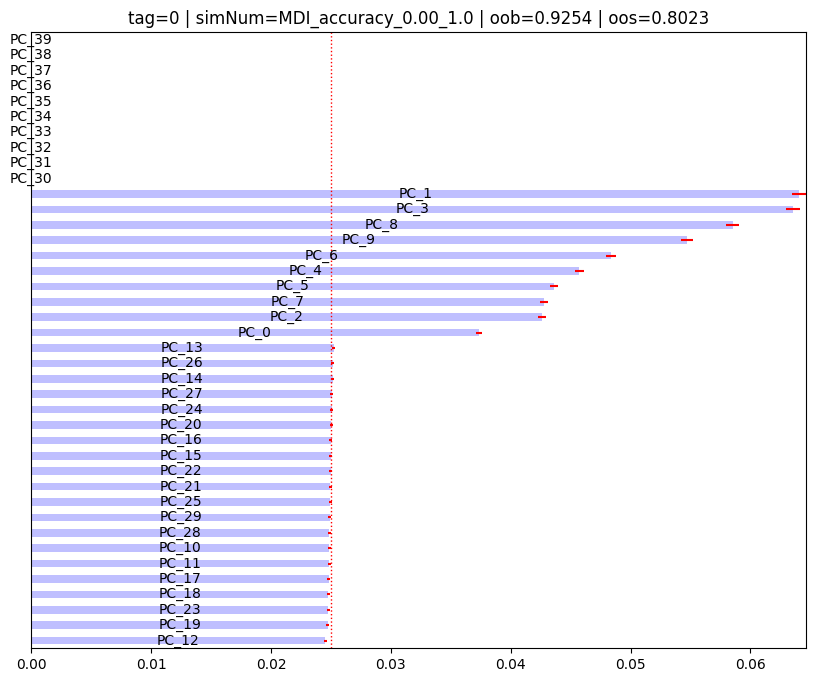

MDA_accuracy_0.00_1.0


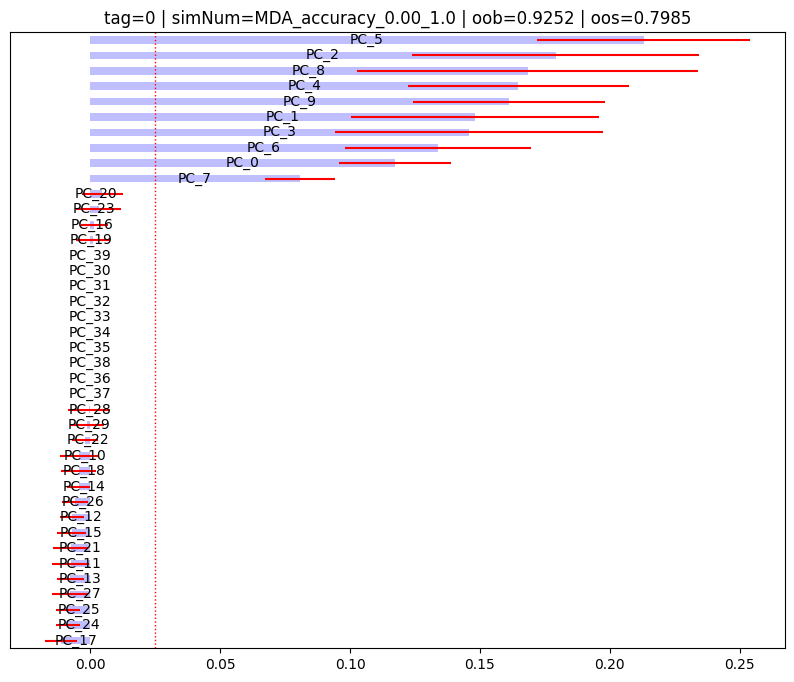

In [4]:
features_importance = test_func(X_1, y)

#### 8.1 (d) Do the three methods agree on what features are important? Why?

No, we can see that SFI has a different result. However, MDA and MDI are agreed that the first 10 features are the important, the reason that they choose different features is that each feature uses a different method to determine what is important. 
MDI use In sample while MDA uses Out of sample. SFI check each feature if its important or not so it has no subtituation effect.

### 8.2 From exercise 1, generate a new dataset (Ẍ , y), where Ẍ is a feature union of X and Ẋ.
#### 8.2 (a) Compute MDI, MDA, and SFI feature importance on (Ẍ , y), where the base estimator is RF.

SFI_accuracy_0.00_1.0


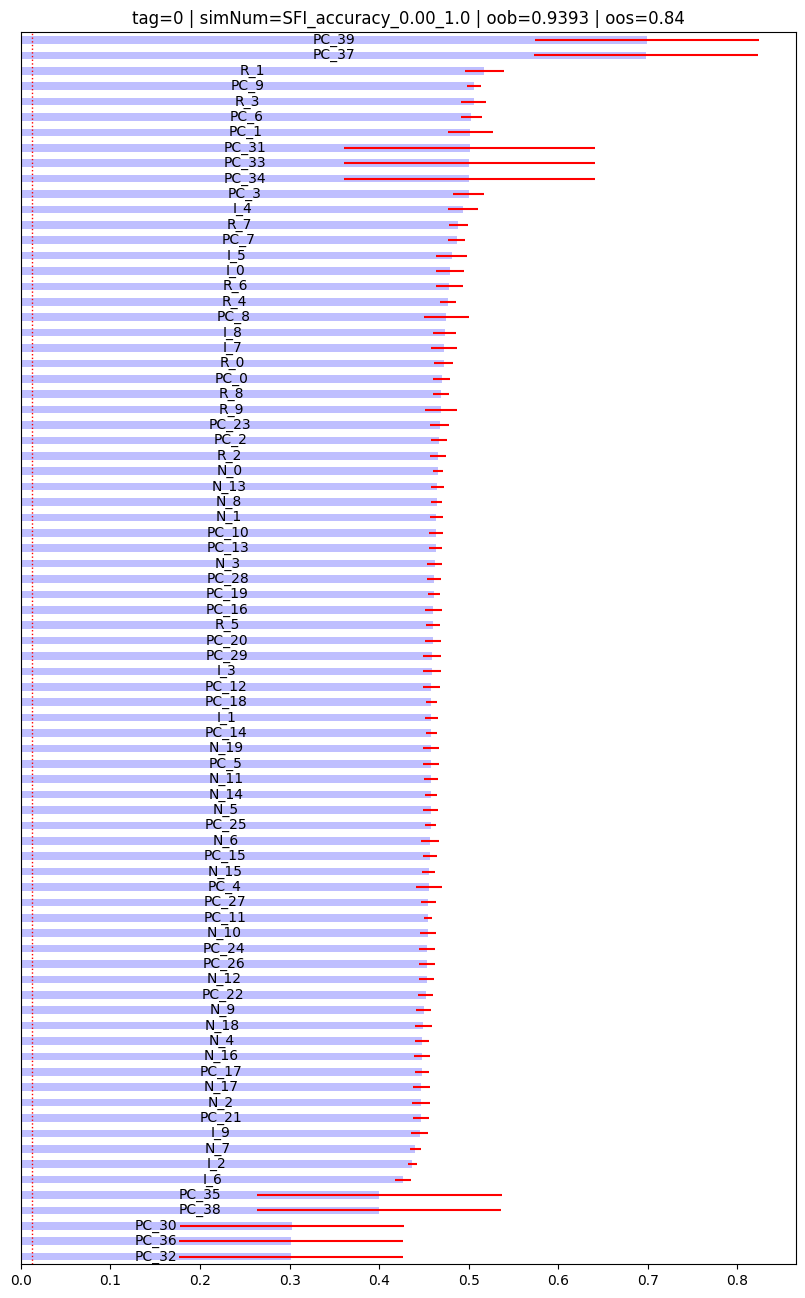

MDI_accuracy_0.00_1.0


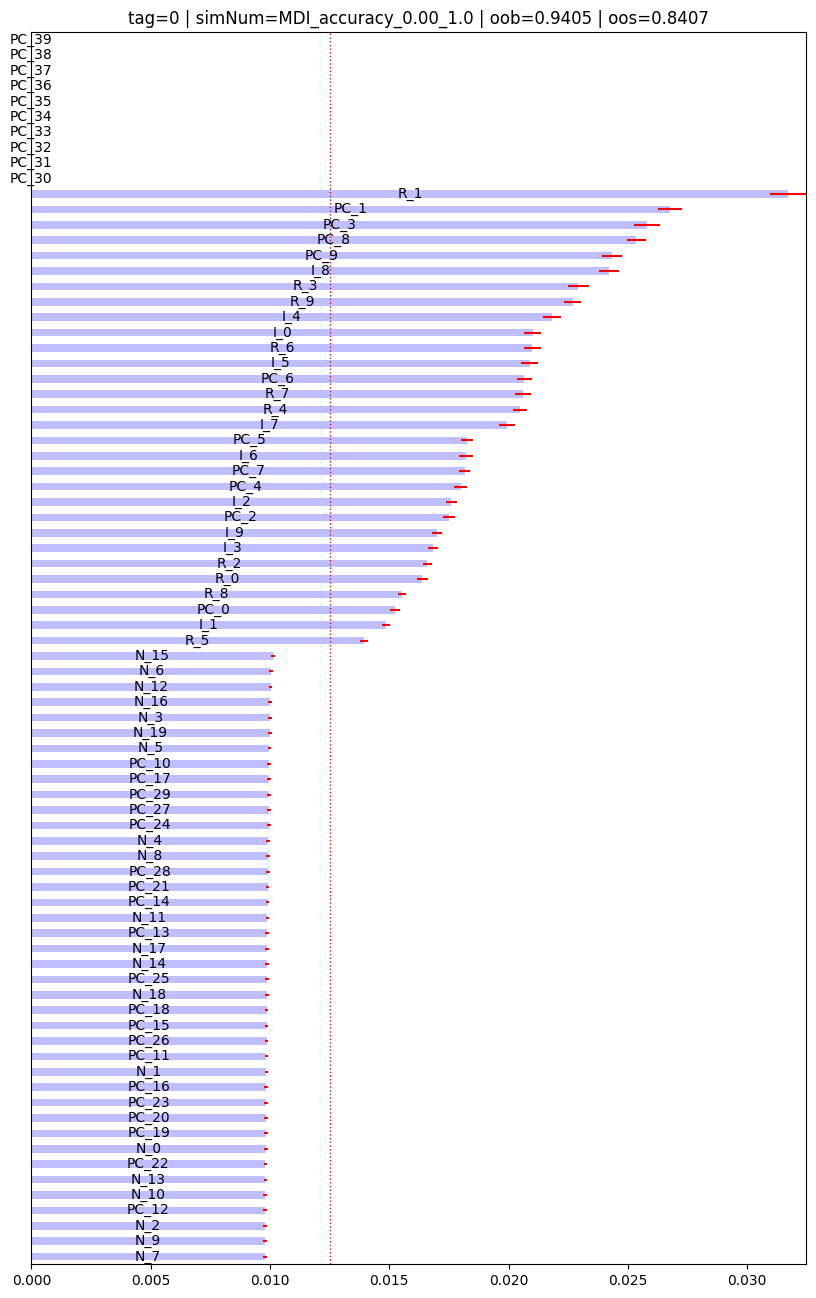

MDA_accuracy_0.00_1.0


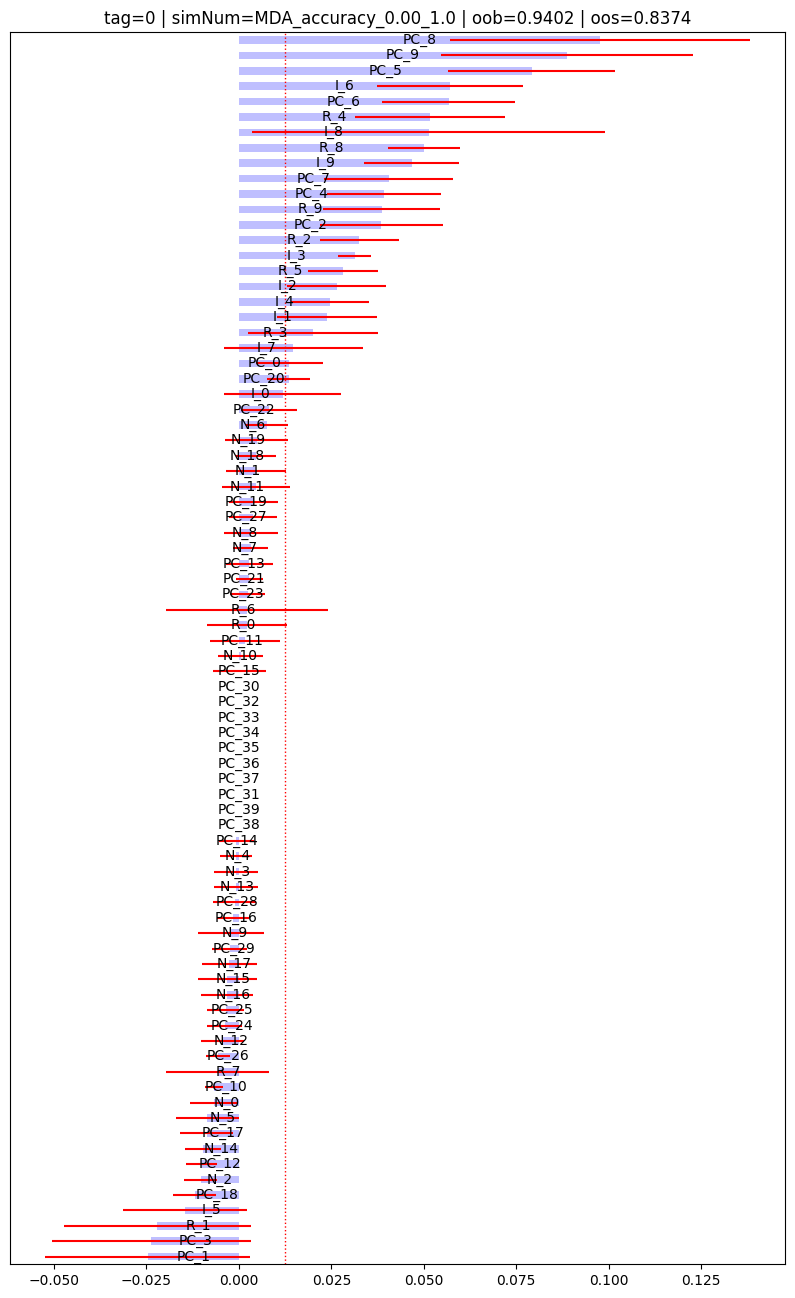

In [6]:
X_2 = pd.concat([X, X_1], axis=1)
features_importance2 = test_func(X_2, y)

In [22]:
SFI_features = [
    'PC_39', 'PC_37', 'PC_34', 'PC_33', 'PC_31',
    'PC_9', 'PC_6', 'PC_1', 'PC_3', 'PC_7'
]
MDI_features = [
    'R_1', 'PC_1', 'PC_3', 'PC_8', 'PC_9',
    'I_8', 'R_3', 'R_9', 'I_4', 'I_0',
    'R_6', 'I_5', 'PC_6', 'R_7', 'R_4'
]
MDA_features = [
    'PC_8', 'PC_9', 'PC_5', 'I_6', 'PC_6', 
    'R_4', 'I_8', 'R_8', 'I_9', 'PC_7'
]


#### 8.2 (b) Do the three methods agree on the important features? Why?
No, the three methods do not agree on the important features. SFI does prefer features from the PCA features,
MDI and MDA have a combination of PC and informative features but with some redundant. All of them didn't choose noise. 

### 8.3 Take the results from exercise 2:
#### 8.3 (a) Drop the most important features according to each method, resulting in a features matrix X⃛.

In [ ]:
X_3_features = set(X_2.columns) - set(SFI_features + MDI_features + MDA_features)
X_3 = X_2[list(X_3_features)]

#### 8.3 (b) Compute MDI, MDA, and SFI feature importance on (X⃛, y), where the base
estimator is RF.

SFI_accuracy_0.00_1.0


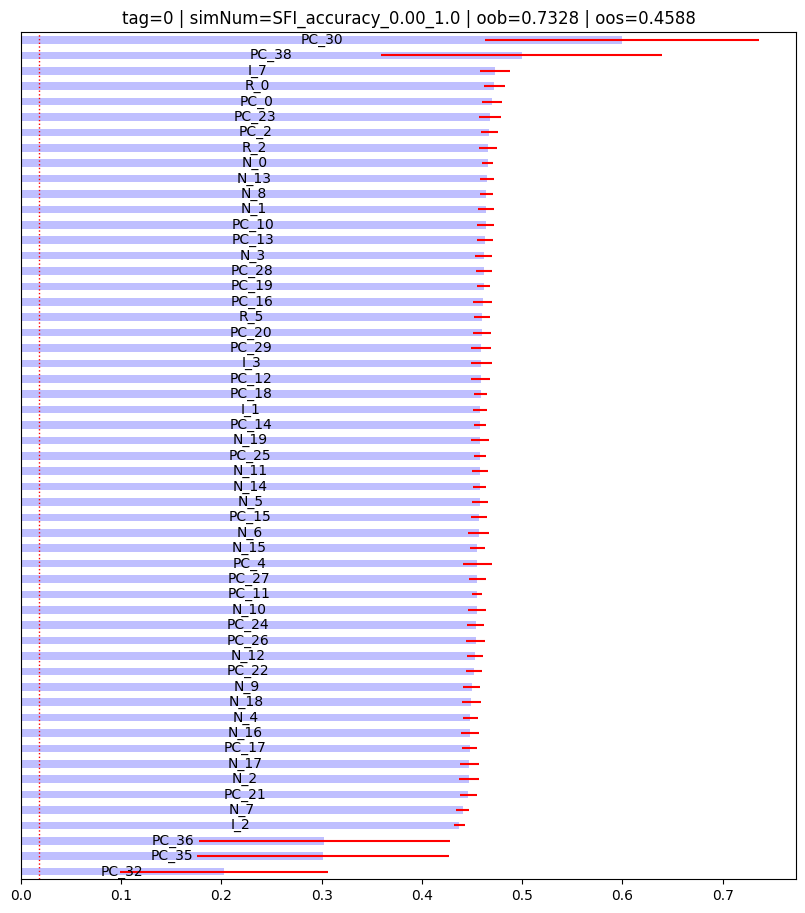

MDI_accuracy_0.00_1.0


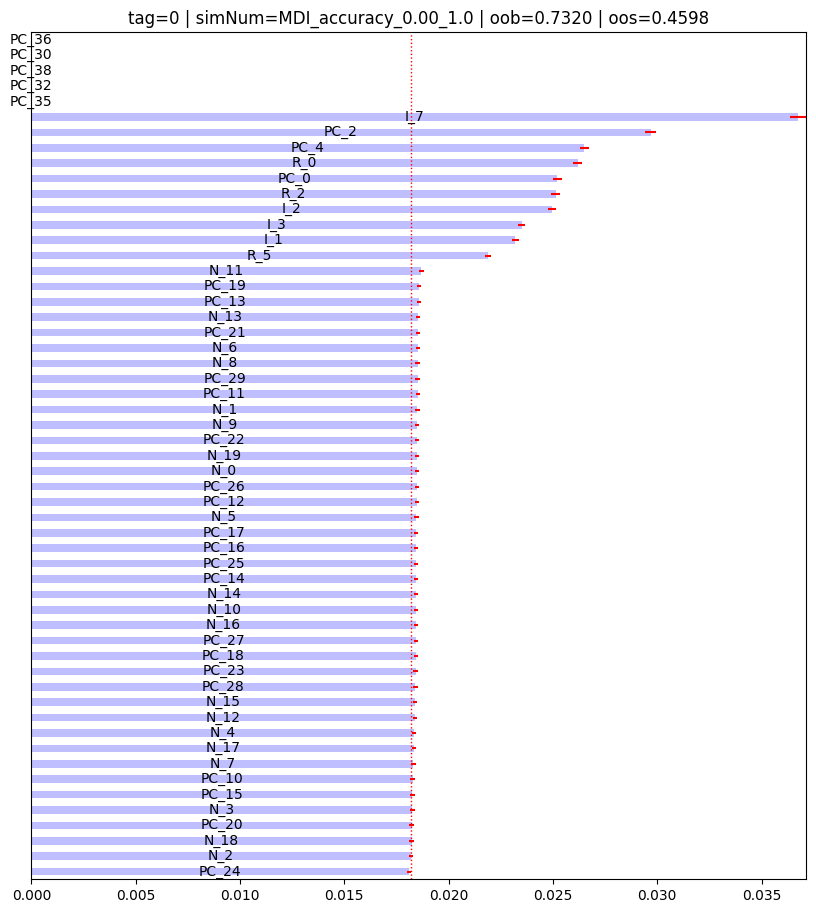

MDA_accuracy_0.00_1.0


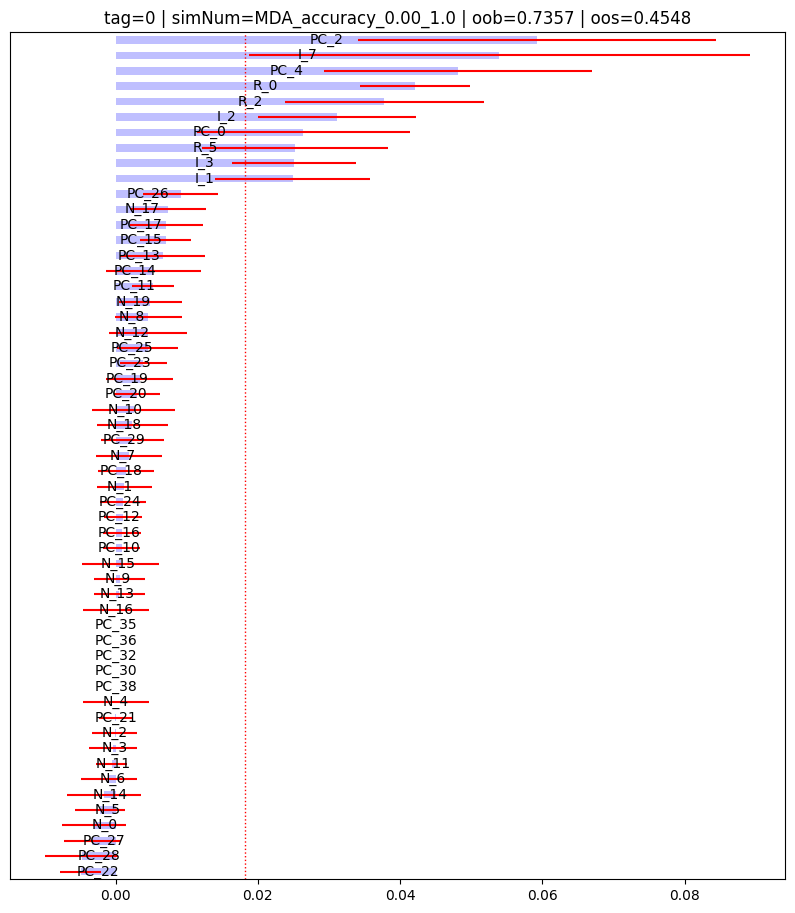

In [16]:
features_importance3 = test_func(X_3, y)

#### 8.3 (c) Do you appreciate significant changes in the rankings of important features, relative to the results from exercise 2?
This is the "new" selected features

In [20]:
# secondary best features before removing them:
secondary_sfi = {"I_5", "I_0", "R_6", "R_4", "PC_8", "I_8", "I_7", "R_0", "PC_0", "R_8", "R_9", "PC_23", "PC_2", "R_2"}
secondary_mdi = {"I_7", "PC_5", "I_6", "PC_7", "PC_4", "I_2", "PC_2", "I_9", "I_3", "R_2", "R_0", "R_8", "PC_0", "I_1", "R_5"}
secondary_mda = {"PC_4", "R_9", "PC_2", "R_2", "I_3", "R_5", "I_2", "I_4", "I_1"}

sfi_features_3 = {"PC_30", "PC_32"}
mdi_features_3 = {"PC_2", "PC_4", "R_0", "PC_0", "R_2", "I_2", "I_3", "I_1", "R_5", "N_11", "I_7"}
mda_features_3 = {"PC_2", "I_7", "PC_4", "R_0", "R_2", "I_2", "PC_0", "R_5", "I_3", "I_1", "PC_26"}

(sfi_features_3 | mdi_features_3 | mda_features_3) - (secondary_sfi | secondary_mdi | secondary_mda)

{'N_11', 'PC_26', 'PC_30', 'PC_32'}

After removing the best features, I evaluate what are the best features, moreover, I check what was the next "best" features from the original evaluation and compare between them. We can see that there are four new features that we can say are worth to add; these results show it isn't really necessary to do a second evaluation

### 8.4 Using the code presented in Section 8.6:
#### 8.4 (a) Generate a dataset (X, y) of 1E6 observations, where 5 features are informative, 5 are redundant and 10 are noise.

In [12]:
X, y = get_test_data(n_features=20, n_informative=5, n_redundant=5, n_samples=int(1e6))

#### 8.4 (b) Split (X, y) into 10 datasets {(Xi, yi)}i=1,…,10, each of 1E5 observations.

In [13]:
Xys = [(X.iloc[i:i + int(1e5)], y.iloc[i:i + int(1e5)]) for i in range(10)]

#### 8.4 (c) Compute the parallelized feature importance (Section 8.5), on each of the 10 datasets, {(Xi, yi)}i=1,…,10.

MDA_accuracy_0.00_1.0


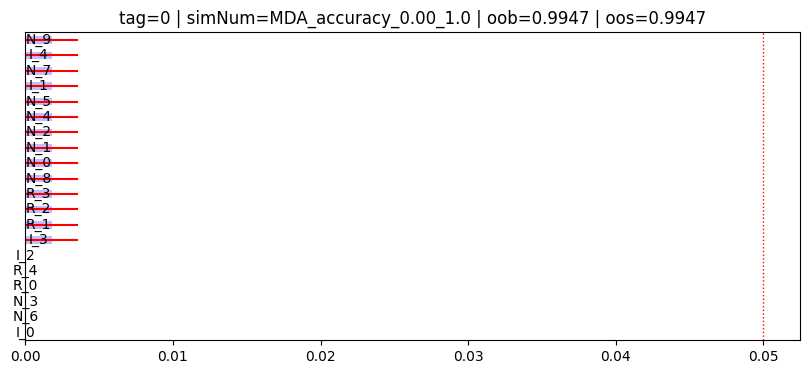

MDA_accuracy_0.00_1.0


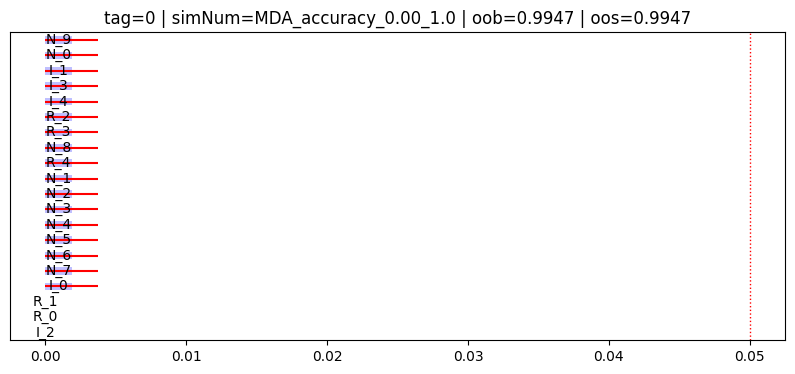

MDA_accuracy_0.00_1.0


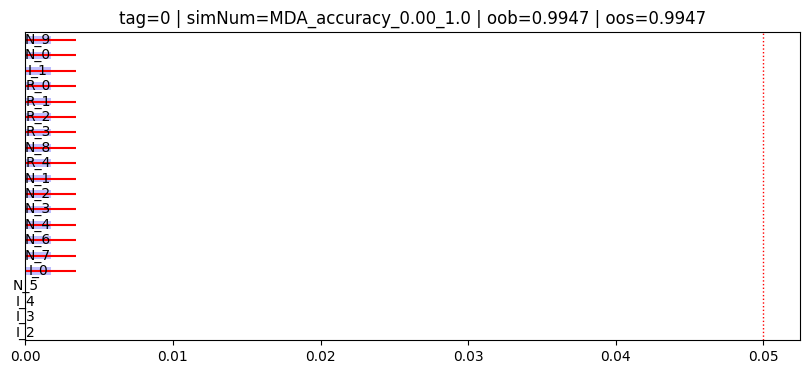

MDA_accuracy_0.00_1.0


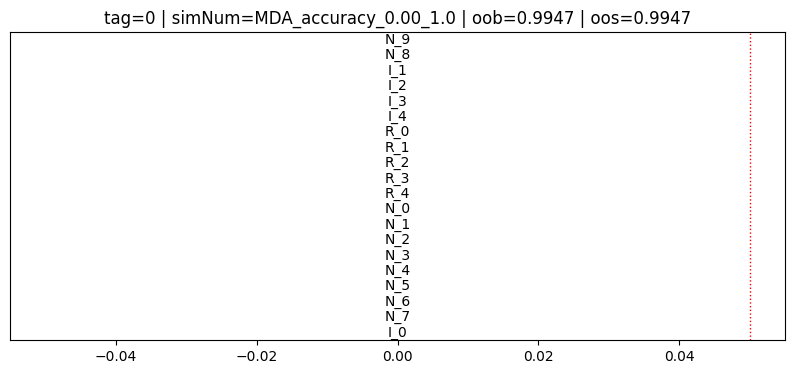

MDA_accuracy_0.00_1.0


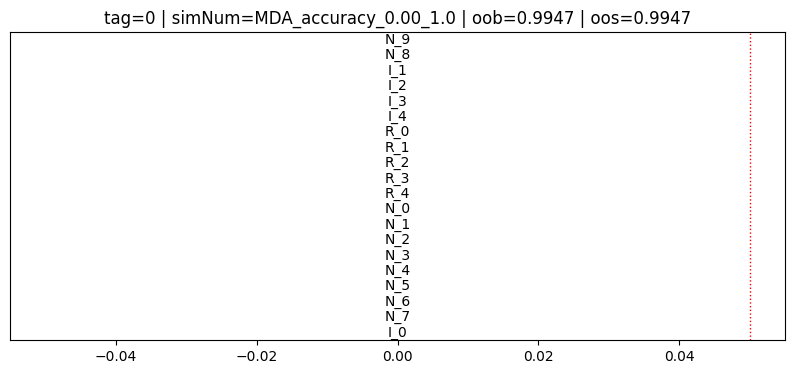

MDA_accuracy_0.00_1.0


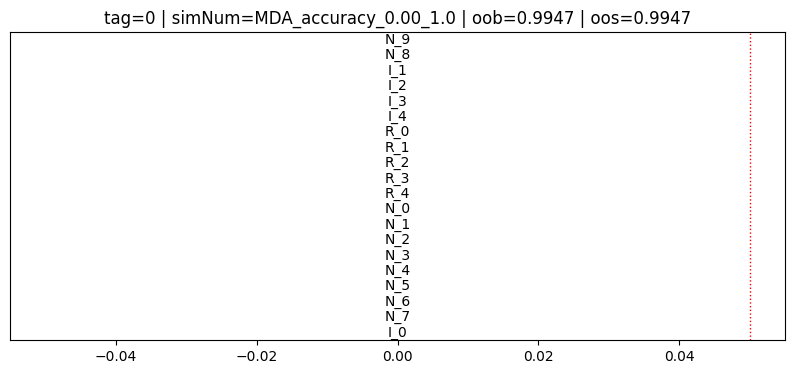

MDA_accuracy_0.00_1.0


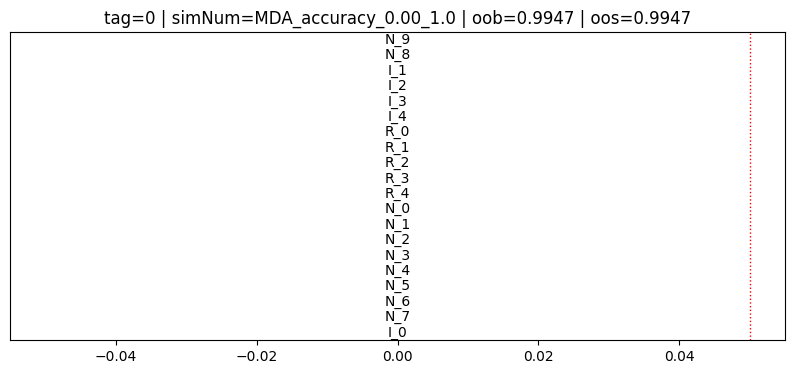

MDA_accuracy_0.00_1.0


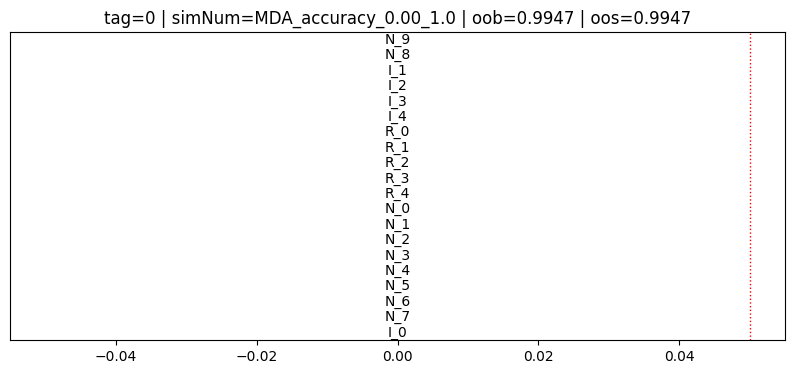

MDA_accuracy_0.00_1.0


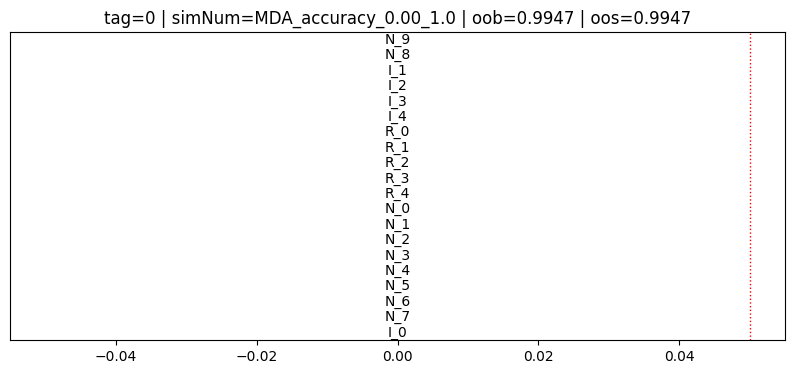

MDA_accuracy_0.00_1.0


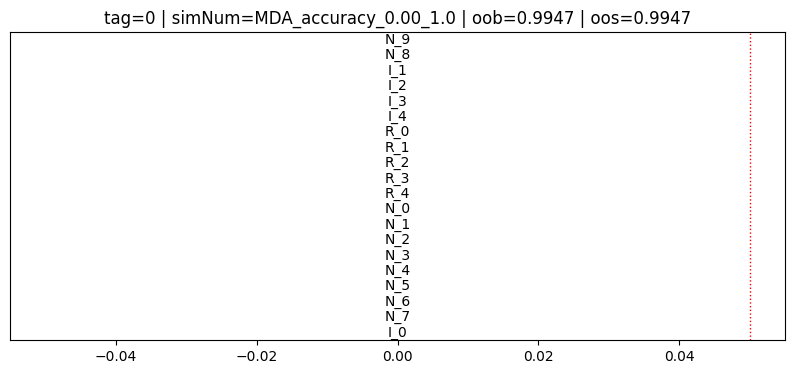

[[{'I': 0.21428571428571427,
   'N': 0.5714285714285713,
   'R': 0.21428571428571427,
   'oob': 0.99469,
   'oos': np.float64(0.9947000000000001),
   'min_w_leaf': 0.0,
   'scoring': 'accuracy',
   'method': 'MDA',
   'max_samples': 1.0,
   'max_features': 1,
   'sim_num': 'MDA_accuracy_0.00_1.0'}],
 [{'I': 0.23529411764705888,
   'N': 0.5882352941176472,
   'R': 0.17647058823529416,
   'oob': 0.99469,
   'oos': np.float64(0.9947000000000001),
   'min_w_leaf': 0.0,
   'scoring': 'accuracy',
   'method': 'MDA',
   'max_samples': 1.0,
   'max_features': 1,
   'sim_num': 'MDA_accuracy_0.00_1.0'}],
 [{'I': 0.12500000000000003,
   'N': 0.5625000000000001,
   'R': 0.31250000000000006,
   'oob': 0.99469,
   'oos': np.float64(0.9947000000000001),
   'min_w_leaf': 0.0,
   'scoring': 'accuracy',
   'method': 'MDA',
   'max_samples': 1.0,
   'max_features': 1,
   'sim_num': 'MDA_accuracy_0.00_1.0'}],
 [{'I': 0.0,
   'N': 0.0,
   'R': 0.0,
   'm': 0.05,
   'oob': 0.9947,
   'oos': np.float64(0.994

In [14]:
[test_func(XY[0], XY[1], methods=['MDA']) for XY in Xys]

MDI_accuracy_0.00_1.0


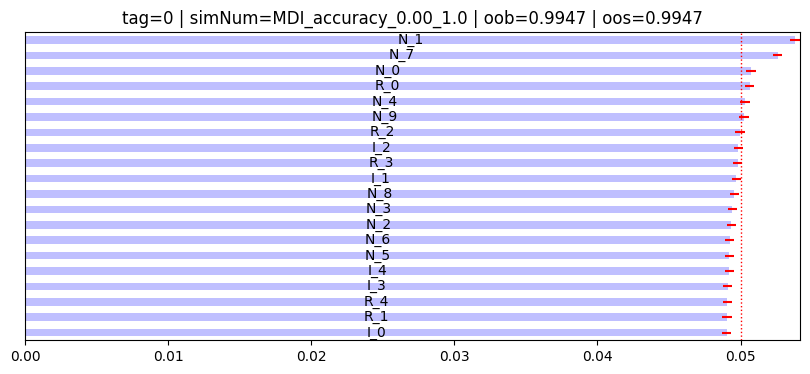

MDI_accuracy_0.00_1.0


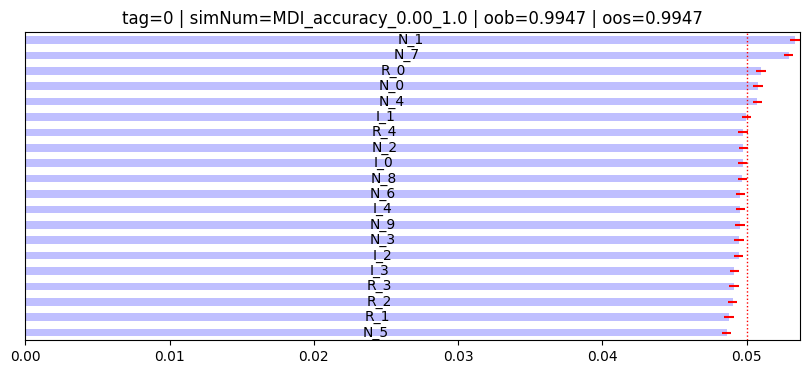

MDI_accuracy_0.00_1.0


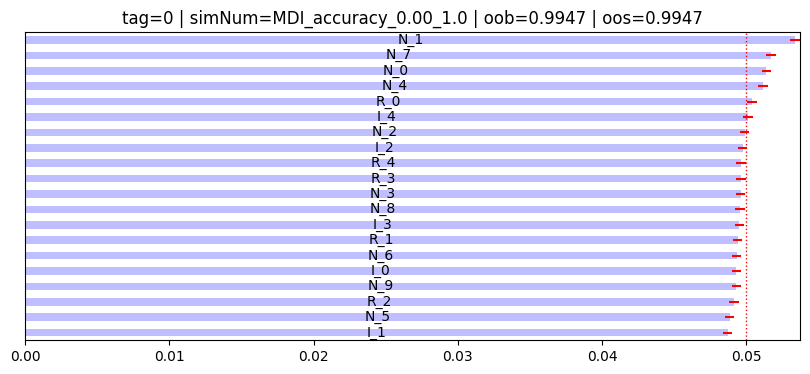

MDI_accuracy_0.00_1.0


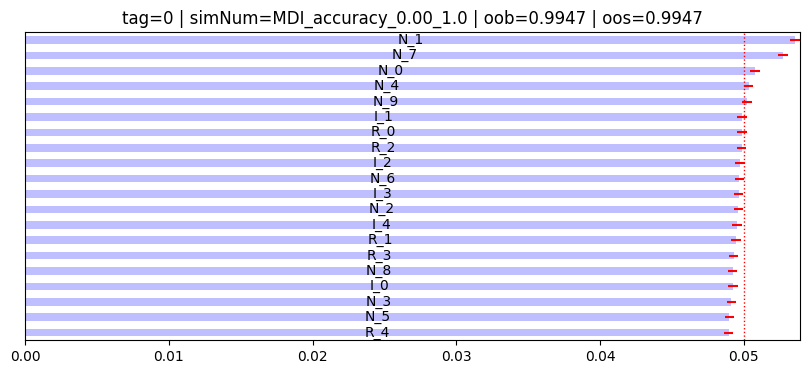

MDI_accuracy_0.00_1.0


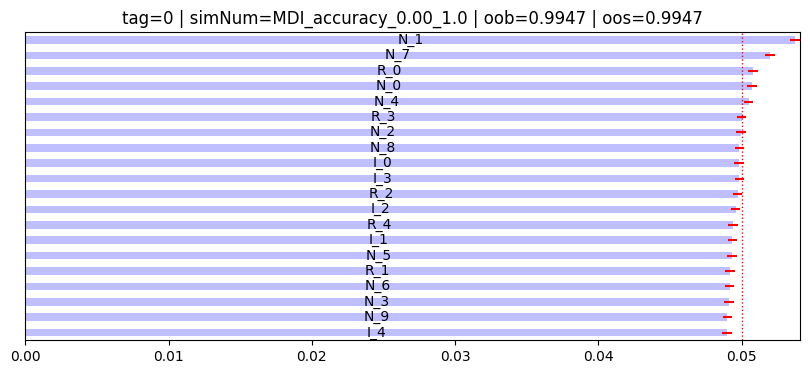

MDI_accuracy_0.00_1.0


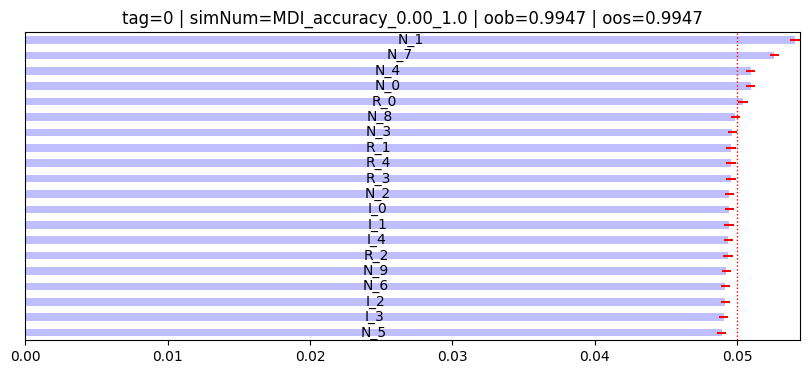

MDI_accuracy_0.00_1.0


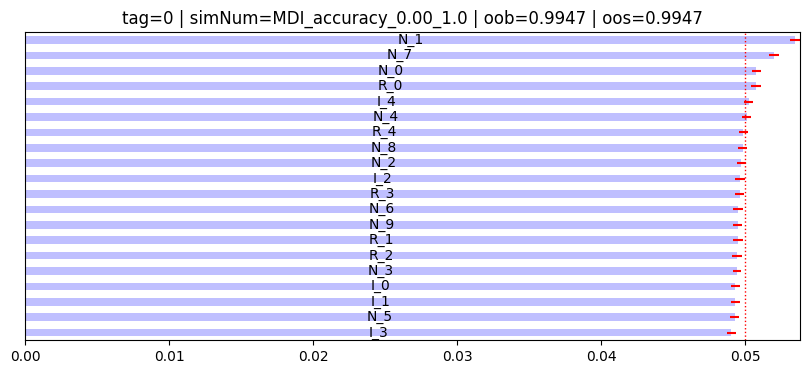

MDI_accuracy_0.00_1.0


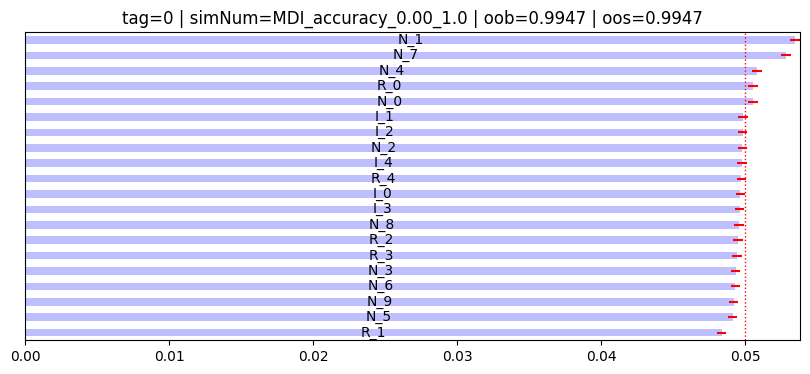

MDI_accuracy_0.00_1.0


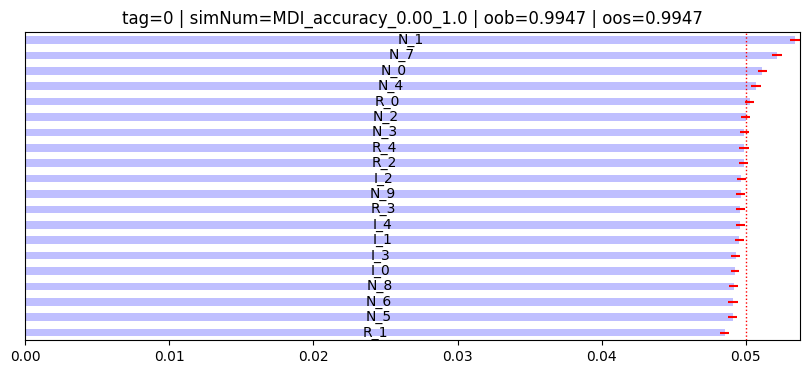

MDI_accuracy_0.00_1.0


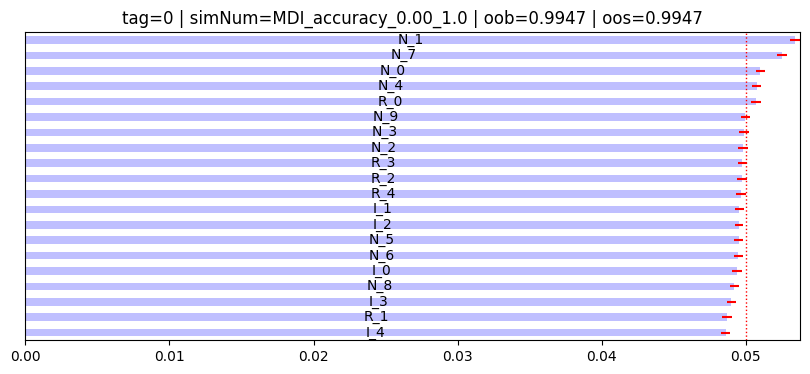

[[{'I': 0.24693606646691266,
   'N': 0.504516942668836,
   'R': 0.24854699086425142,
   'oob': 0.99469,
   'oos': np.float64(0.9947000000000001),
   'min_w_leaf': 0.0,
   'scoring': 'accuracy',
   'method': 'MDI',
   'max_samples': 1.0,
   'max_features': 1,
   'sim_num': 'MDI_accuracy_0.00_1.0'}],
 [{'I': 0.24784516829348513,
   'N': 0.5044796076577098,
   'R': 0.24767522404880507,
   'oob': 0.99469,
   'oos': np.float64(0.9947000000000001),
   'min_w_leaf': 0.0,
   'scoring': 'accuracy',
   'method': 'MDI',
   'max_samples': 1.0,
   'max_features': 1,
   'sim_num': 'MDI_accuracy_0.00_1.0'}],
 [{'I': 0.2474142552250499,
   'N': 0.5043138767309163,
   'R': 0.24827186804403378,
   'oob': 0.99469,
   'oos': np.float64(0.9947000000000001),
   'min_w_leaf': 0.0,
   'scoring': 'accuracy',
   'method': 'MDI',
   'max_samples': 1.0,
   'max_features': 1,
   'sim_num': 'MDI_accuracy_0.00_1.0'}],
 [{'I': 0.24809110999220815,
   'N': 0.5044695578800952,
   'R': 0.24743933212769667,
   'oob': 0.9

In [15]:
[test_func(XY[0], XY[1], methods=['MDI']) for XY in Xys]

#### 8.4 (d) Compute the stacked feature importance on the combined dataset (X, y).

MDA_accuracy_0.00_1.0


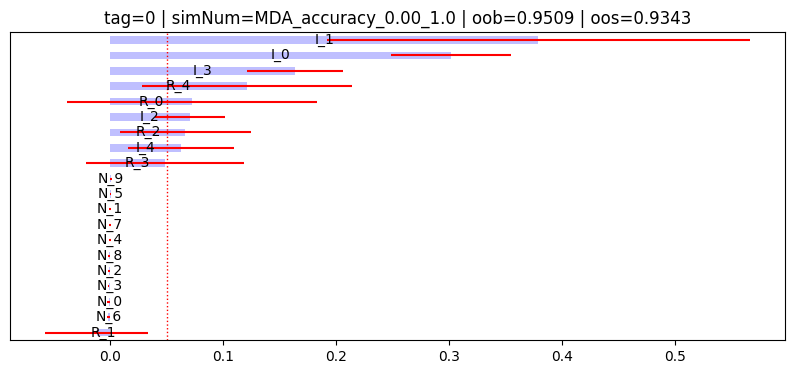

MDI_accuracy_0.00_1.0


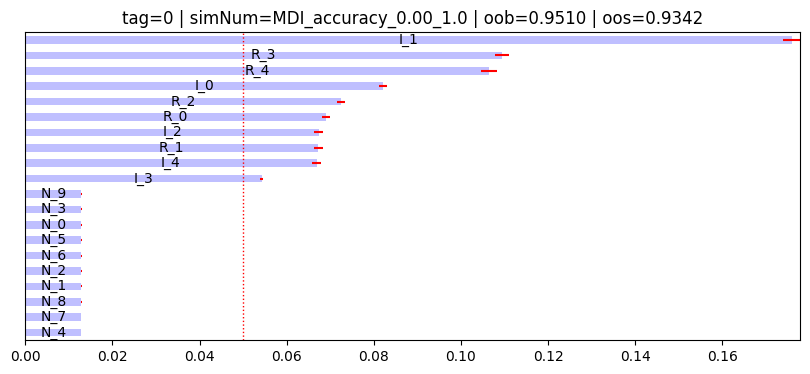

[{'I': 0.7482090865702475,
  'N': -0.005034549774645378,
  'R': 0.22700355396333402,
  'oob': 0.950876,
  'oos': np.float64(0.9343059999999997),
  'min_w_leaf': 0.0,
  'scoring': 'accuracy',
  'method': 'MDA',
  'max_samples': 1.0,
  'max_features': 1,
  'sim_num': 'MDA_accuracy_0.00_1.0'},
 {'I': 0.44649955459129936,
  'N': 0.12877581592813234,
  'R': 0.42472462948056827,
  'oob': 0.951006,
  'oos': np.float64(0.9342479999999996),
  'min_w_leaf': 0.0,
  'scoring': 'accuracy',
  'method': 'MDI',
  'max_samples': 1.0,
  'max_features': 1,
  'sim_num': 'MDI_accuracy_0.00_1.0'}]

In [16]:
test_func(X, y, methods=['MDA', 'MDI'])

#### 8.4 (e) What causes the discrepancy between the two? Which one is more reliable?
The discrepancy is caused by less bias on each smaller dataset. The stacked feature importance is more reliable because it uses more data and has less chance to be overfitting.

We can see that the concurrent features selection didnt work so well while that stacked feature importance worked much, much better.

### 8.5 Repeat all MDI calculations from exercises 1–4, but this time allows for masking

#### 8.5 1)

MDI_accuracy_0.00_1.0


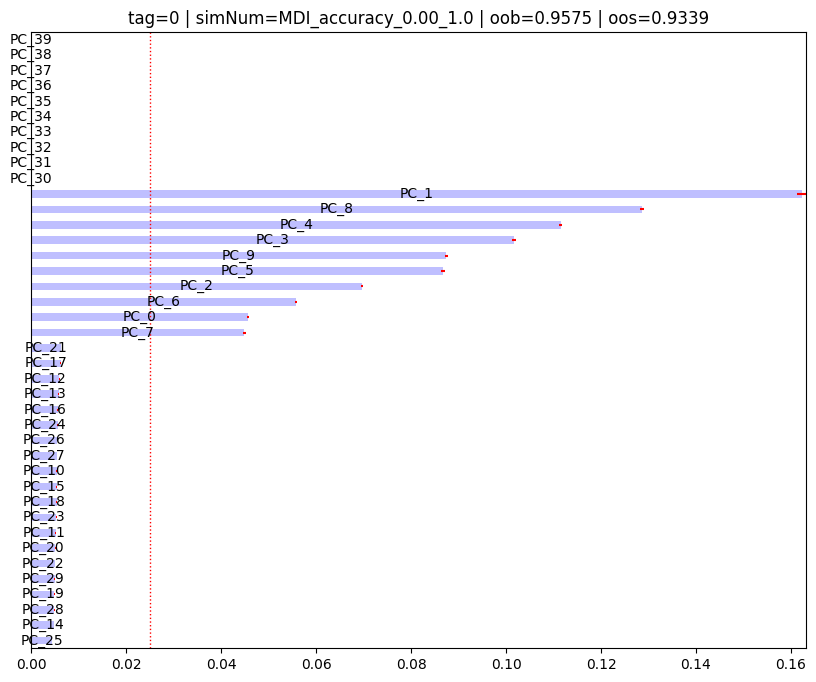

[{'P': 1.0,
  'oob': 0.9575,
  'oos': np.float64(0.9338999999999998),
  'min_w_leaf': 0.0,
  'scoring': 'accuracy',
  'method': 'MDI',
  'max_samples': 1.0,
  'max_features': None,
  'sim_num': 'MDI_accuracy_0.00_1.0'}]

In [17]:
X, y = get_test_data(n_features=40, n_informative=10, n_redundant=10, n_samples=10000)
pca = PCA()
X_1 = pca.fit_transform(X)
X_1 = pd.DataFrame(X_1, columns=[f'PC_{i}' for i in np.arange(len(X_1[1]))], index=X.index)
test_func(X_1, y, methods=['MDI'], max_features=[None])

#### 8.5 2)

MDI_accuracy_0.00_1.0


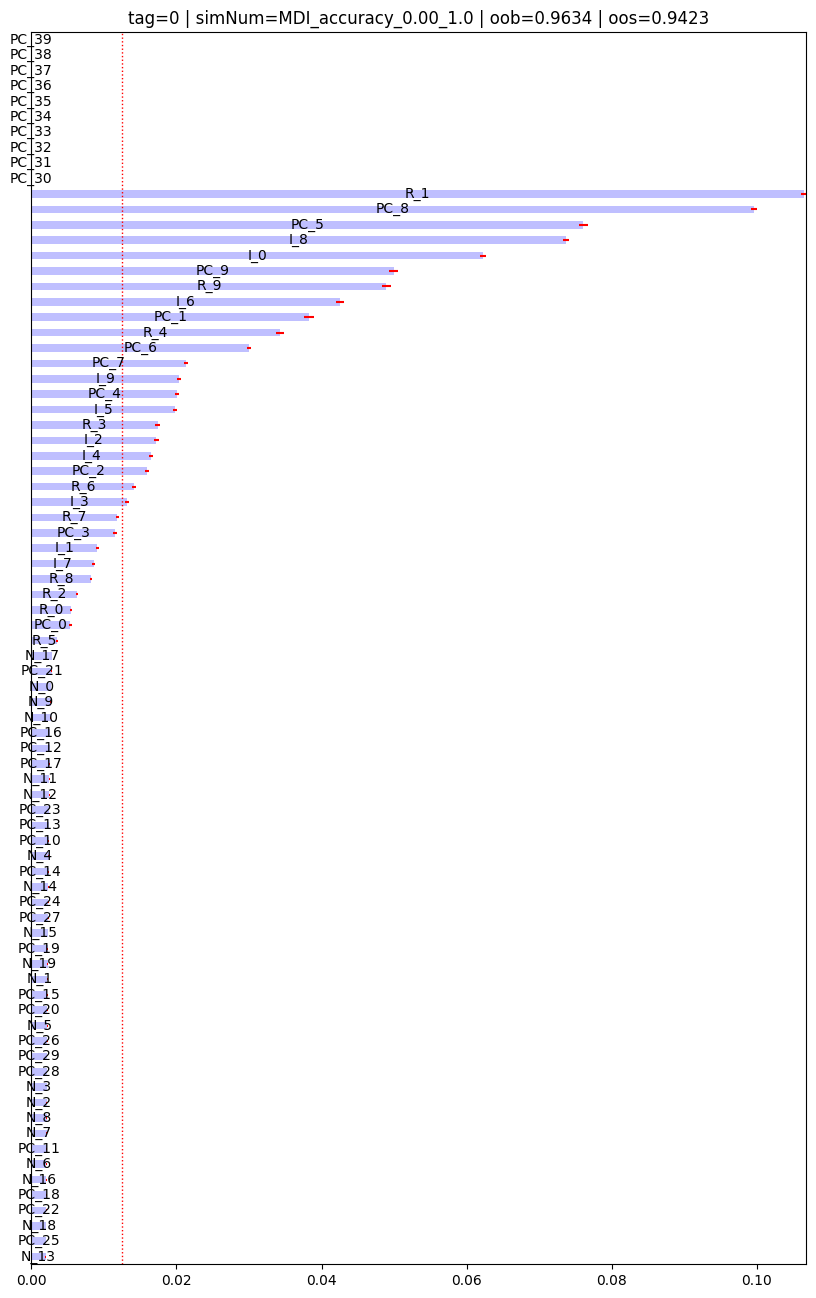

[{'I': 0.2830892894253881,
  'N': 0.04612151130522876,
  'P': 0.414152408592616,
  'R': 0.25663679067676715,
  'oob': 0.9634,
  'oos': np.float64(0.9423),
  'min_w_leaf': 0.0,
  'scoring': 'accuracy',
  'method': 'MDI',
  'max_samples': 1.0,
  'max_features': None,
  'sim_num': 'MDI_accuracy_0.00_1.0'}]

In [18]:
X_2 = pd.concat([X, X_1], axis=1)
test_func(X_2, y, methods=['MDI'], max_features=[None])

#### 8.5 3)

MDI_accuracy_0.00_1.0


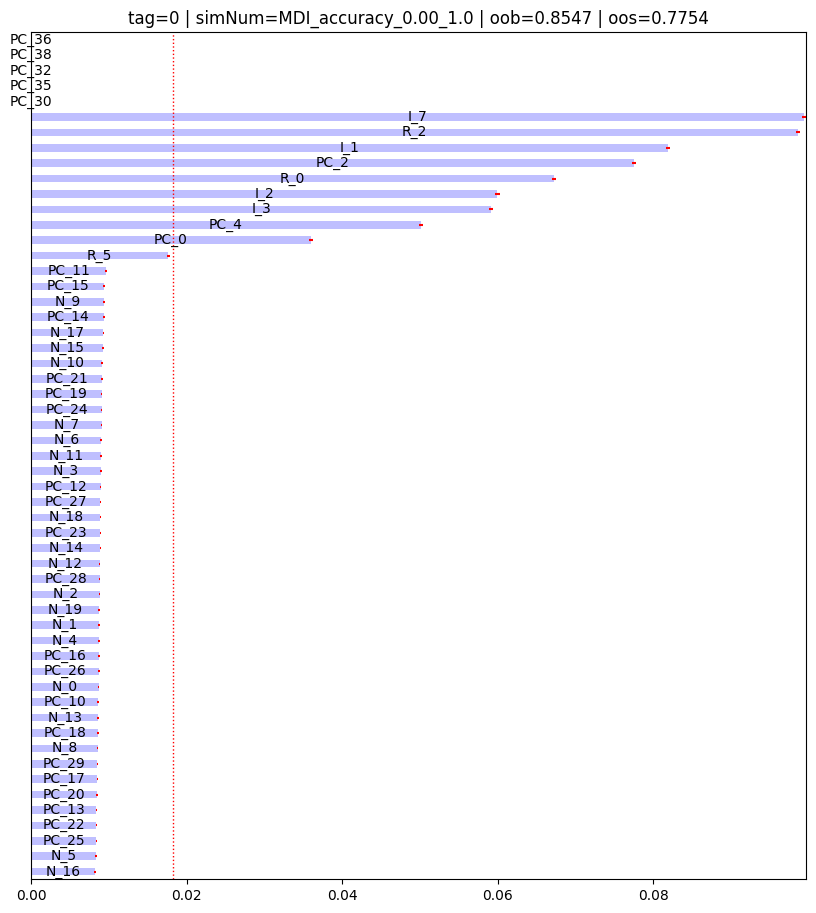

[{'I': 0.3004662269234718,
  'N': 0.17650039264751052,
  'P': 0.33953464349823276,
  'R': 0.1834987369307849,
  'oob': 0.8547,
  'oos': np.float64(0.7754000000000001),
  'min_w_leaf': 0.0,
  'scoring': 'accuracy',
  'method': 'MDI',
  'max_samples': 1.0,
  'max_features': None,
  'sim_num': 'MDI_accuracy_0.00_1.0'}]

In [23]:
X_3_features = set(X_2.columns) - set(SFI_features + MDI_features + MDA_features)
X_3 = X_2[list(X_3_features)]
test_func(X_3, y, methods=['MDI'], max_features=[None])

#### 8.5 3)

Concurrent feature importance
MDI_accuracy_0.00_1.0


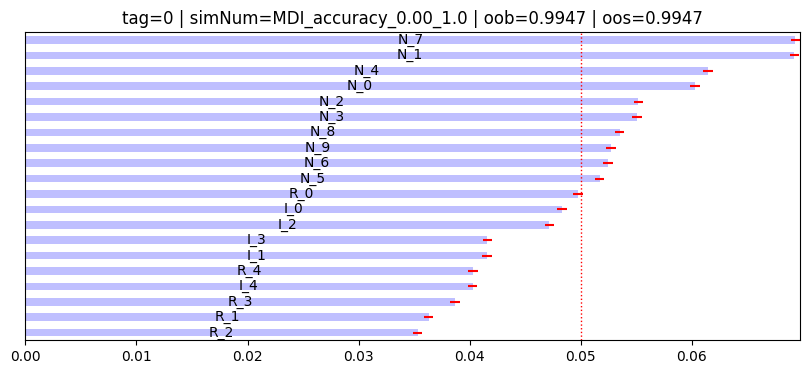

MDI_accuracy_0.00_1.0


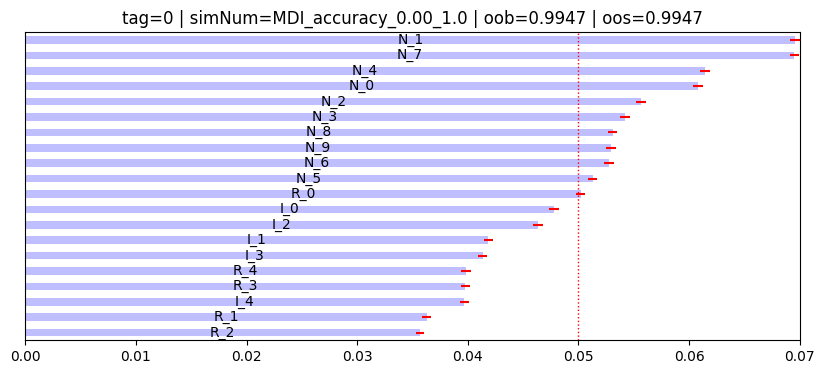

MDI_accuracy_0.00_1.0


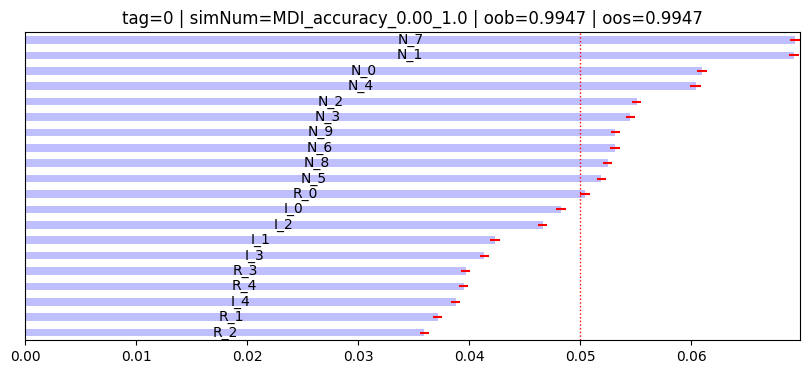

MDI_accuracy_0.00_1.0


In [ ]:
X, y = get_test_data(n_features=20, n_informative=5, n_redundant=5, n_samples=int(1e6))
Xys = [(X.iloc[i:i + int(1e5)], y.iloc[i:i + int(1e5)]) for i in range(10)]
print('Concurrent feature importance')
[test_func(XY[0], XY[1], methods=['MDI'], max_features=[None]) for XY in Xys]

print('Stacked feature importance')
test_func(X, y, methods=['MDI'], max_features=[None])